In [1]:
# Time Series With Deep Learning

In [7]:
pip install tenserflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tenserflow (from versions: none)
ERROR: No matching distribution found for tenserflow


#LSTM LONG SHORT TİME MEMORY gelecek zaman serisi metin serisi tahmin eder

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense, LSTM

In [9]:
df=pd.read_csv('Google_Stock_Price_Train.csv')

In [6]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [11]:
train_set=df.iloc[:,1:2].values

In [12]:
sc=MinMaxScaler()

In [13]:
train_set=sc.fit_transform(train_set)

In [15]:
x_train=train_set[0:1257]
y_train=train_set[1:1258]

In [16]:
model=Sequential()
model.add(LSTM(units=4, activation='sigmoid', input_shape=(None,1)))
model.add(Dense(units=1))

C:\Anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [20]:
model.fit(x_train,y_train,batch_size=32,epochs=200)

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2149
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1509
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1116
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0893
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0779
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0724
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0695
Epoch 8/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0678
Epoch 9/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0665
Epoch 10/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0653
Epoch 11/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0640
Epoch 12/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0627
Epoch 13/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0615
Epoch 14/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0601
Epoch 15/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0588
Epoc

In [21]:
test=pd.read_csv('Google_Stock_Price_Test.csv')

In [22]:
test=test.iloc[:,1:2].values

In [27]:
test_set=sc.transform(test)

In [28]:
tahmin=model.predict(test_set)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


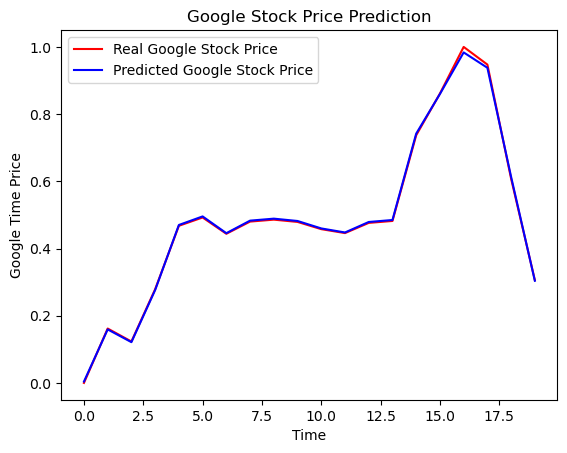

In [29]:
plt.plot(test_set, color = 'red', label = 'Real Google Stock Price')
plt.plot(tahmin, color = 'blue', label = 'Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Time Price')
plt.legend()
plt.show()

